## Importação das Dependências e Configurações

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scripts.outliers import outlier_iqr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

## Análise Inicial dos Datasets

In [3]:
df_avl_suspeitas = pd.read_csv("../data/projeto_02_avaliacoes_suspeitas.csv")
df_vendas = pd.read_csv("../data/projeto_02_ecommerce_vendas.csv")
df_vendedores = pd.read_csv("../data/projeto_02_vendedores_perfil.csv")

Descrição dos Dados

In [4]:
print('Informações Iniciais dos DataFrames -- Vendedores')
print('--'*100)
print(df_vendedores.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendedores
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    object 
 1   nome_loja            120 non-null    object 
 2   data_cadastro        120 non-null    object 
 3   cidade               120 non-null    object 
 4   estado               120 non-null    object 
 5   categoria_principal  120 non-null    object 
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), objec

In [5]:
print('Informações Iniciais dos DataFrames -- Vendas')
print('--'*100)
print(df_vendas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   object 
 1   data_pedido     8000 non-null   object 
 2   hora_pedido     8000 non-null   object 
 3   vendedor_id     8000 non-null   object 
 4   categoria       8000 non-null   object 
 5   produto_id      8000 non-null   object 
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   object 
 11  status_pedido   8000 non-null   object 
 12  nota_avalia

In [6]:
print('Informações Iniciais dos DataFrames -- Avaliações suspeitas')
print('--'*100)
print(df_avl_suspeitas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Avaliações suspeitas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   avaliacao_id        3000 non-null   object
 1   vendedor_id         3000 non-null   object
 2   comprador_id        3000 non-null   object
 3   data_avaliacao      3000 non-null   object
 4   data_criacao_conta  3000 non-null   object
 5   nota                3000 non-null   int64 
 6   ip_origem           3000 non-null   object
 7   texto_avaliacao     2668 non-null   object
dtypes: int64(1), object(7)
memory usage: 187.6+ KB
None




## Transformando Dados

In [7]:
df_vendas['data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')

df_vendas['quantidade'] = df_vendas['quantidade'].astype("str").replace("nan", "0").astype("int")
df_vendas['preco_unitario'] = df_vendas['preco_unitario'].astype("float")
df_vendas['frete'] = df_vendas['frete'].fillna("-1").astype("float")

df_vendedores['_data_cadastro_dt'] = pd.to_datetime(df_vendedores['data_cadastro'],  format='%Y-%m-%d')

df_avl_suspeitas['data_avaliacao_dt'] = pd.to_datetime(df_avl_suspeitas['data_avaliacao'], format='%Y-%m-%d')
df_avl_suspeitas['data_criacao_conta_dt'] = pd.to_datetime(df_avl_suspeitas['data_criacao_conta'], format='%Y-%m-%d')
df_avl_suspeitas['texto_avaliacao'] = df_avl_suspeitas['texto_avaliacao'].fillna("Sem Comentário Explícito")


# Detecção de Duplicadas

In [8]:
dup_vendas_pedido = df_vendas.duplicated(subset=['pedido_id']).sum()
dup_vendas_item = df_vendas.duplicated(subset=['pedido_id', 'produto_id']).sum()

print('VENDAS')
print(f'  Linhas duplicadas por pedido_id: {dup_vendas_pedido}')
print(f'  Linhas duplicadas por (pedido_id, produto_id): {dup_vendas_item}')
if dup_vendas_item > 0:
    n_antes = len(df_vendas)
    df_vendas = df_vendas.drop_duplicates(subset=['pedido_id', 'produto_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendas)} duplicatas. Total de linhas: {len(df_vendas)}')

VENDAS
  Linhas duplicadas por pedido_id: 0
  Linhas duplicadas por (pedido_id, produto_id): 0


In [9]:
dup_vendedor = df_vendedores.duplicated(subset=['vendedor_id']).sum()
print('VENDEDORES')
print(f'  Linhas duplicadas por vendedor_id: {dup_vendedor}')
if dup_vendedor > 0:
    n_antes = len(df_vendedores)
    df_vendedores = df_vendedores.drop_duplicates(subset=['vendedor_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_vendedores)} duplicatas. Total de linhas: {len(df_vendedores)}')

VENDEDORES
  Linhas duplicadas por vendedor_id: 0


In [10]:
dup_aval_id = df_avl_suspeitas.duplicated(subset=['avaliacao_id']).sum()
dup_aval_multi = df_avl_suspeitas.duplicated(subset=['vendedor_id', 'comprador_id', 'data_avaliacao']).sum()

print('AVALIAÇÕES SUSPEITAS')
print(f'  Linhas duplicadas por avaliacao_id: {dup_aval_id}')
print(f'  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): {dup_aval_multi}')
if dup_aval_id > 0:
    n_antes = len(df_avl_suspeitas)
    df_avl_suspeitas = df_avl_suspeitas.drop_duplicates(subset=['avaliacao_id'], keep='first')
    print(f'  -> Removidas {n_antes - len(df_avl_suspeitas)} duplicatas por avaliacao_id. Total de linhas: {len(df_avl_suspeitas)}')

AVALIAÇÕES SUSPEITAS
  Linhas duplicadas por avaliacao_id: 0
  Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): 0


# Investigações Base

Distribuição entre tipos de vendedores: Verificados e Não Verificados

In [11]:
df_vendedores[['verificado']].value_counts(normalize='percent')

verificado
False         0.53
True          0.47
Name: proportion, dtype: float64

In [12]:
verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == True]['vendedor_id'].values)
nao_verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == False]['vendedor_id'].values)

print("Verificados")
print(verificados.size)
print(verificados)

print("--------------------------------")

print("Não Verificados")
print(nao_verificados.size)
print(nao_verificados)


Verificados
57
['VEND-0003' 'VEND-0006' 'VEND-0007' 'VEND-0009' 'VEND-0010' 'VEND-0015'
 'VEND-0016' 'VEND-0018' 'VEND-0019' 'VEND-0020' 'VEND-0022' 'VEND-0025'
 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0032' 'VEND-0041'
 'VEND-0047' 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060' 'VEND-0062'
 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0067' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0077' 'VEND-0084' 'VEND-0085'
 'VEND-0086' 'VEND-0091' 'VEND-0092' 'VEND-0096' 'VEND-0098' 'VEND-0100'
 'VEND-0103' 'VEND-0107' 'VEND-0108' 'VEND-0109' 'VEND-0111' 'VEND-0112'
 'VEND-0116' 'VEND-0117' 'VEND-0118']
--------------------------------
Não Verificados
63
['VEND-0001' 'VEND-0002' 'VEND-0004' 'VEND-0005' 'VEND-0008' 'VEND-0011'
 'VEND-0012' 'VEND-0013' 'VEND-0014' 'VEND-0017' 'VEND-0021' 'VEND-0023'
 'VEND-0024' 'VEND-0030' 'VEND-0031' 'VEND-0033' 'VEND-0034' 'VEND-0035'
 'VEND-0036' 'VEND-

Verificação de Vendas

In [13]:
df_vendas_merged = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id')
df_vendas_merged

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,data_pedido_dt,_hora_pedido,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,NaN,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,NaN,2023-10-21,1900-01-01 16:01:00,False
3,PED-000004,2023-10-29,18:53,VEND-0083,Eletrônicos,PROD-0282,620.43,2,1240.86,10.89,MG,Entregue,5.0,2023-10-29,1900-01-01 18:53:00,False
4,PED-000005,2024-03-21,09:13,VEND-0025,Acessórios,PROD-0141,36.96,1,36.96,35.60,MA,Entregue,4.0,2024-03-21,1900-01-01 09:13:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,PED-007996,2024-07-29,12:33,VEND-0058,Acessórios,PROD-0359,78.62,1,78.62,19.67,CE,Cancelado,NaN,2024-07-29,1900-01-01 12:33:00,True
7996,PED-007997,2024-04-11,06:56,VEND-0039,Moda Feminina,PROD-0025,121.46,3,364.38,40.36,PE,Entregue,3.0,2024-04-11,1900-01-01 06:56:00,False
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.0,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,1337.26,39.09,SP,Em trânsito,NaN,2023-04-23,1900-01-01 10:34:00,False


In [16]:
101.92*2	

203.84

In [17]:
valor_total_incorreto = df_vendas_merged[
    (df_vendas_merged['preco_unitario'] * df_vendas_merged['quantidade']) != df_vendas_merged['valor_total']
]

valor_total_incorreto

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,data_pedido_dt,_hora_pedido,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
12,PED-000013,2023-09-20,08:44,VEND-0029,Infantil,PROD-0252,101.92,2,203.85,18.88,RS,Entregue,5.0,2023-09-20,1900-01-01 08:44:00,True
22,PED-000023,2023-09-12,12:02,VEND-0063,Esporte & Lazer,PROD-0032,234.61,2,469.23,10.73,CE,Cancelado,NaN,2023-09-12,1900-01-01 12:02:00,True
23,PED-000024,2024-02-18,06:28,VEND-0120,Casa & Decoração,PROD-0033,253.16,2,506.33,42.73,CE,Entregue,5.0,2024-02-18,1900-01-01 06:28:00,False
25,PED-000026,2024-03-06,04:15,VEND-0099,Eletrônicos,PROD-0331,535.58,3,1606.73,41.12,PB,Entregue,4.0,2024-03-06,1900-01-01 04:15:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,PED-007968,2023-12-12,12:34,VEND-0083,Esporte & Lazer,PROD-0290,159.50,3,478.49,34.98,PR,Devolvido,NaN,2023-12-12,1900-01-01 12:34:00,False
7975,PED-007976,2024-06-01,15:23,VEND-0035,Esporte & Lazer,PROD-0410,194.09,2,388.17,36.39,RS,Devolvido,NaN,2024-06-01,1900-01-01 15:23:00,False
7978,PED-007979,2024-01-31,18:43,VEND-0013,Infantil,PROD-0390,109.19,3,327.56,23.56,BA,Cancelado,NaN,2024-01-31,1900-01-01 18:43:00,False
7992,PED-007993,2023-03-20,18:51,VEND-0096,Moda Feminina,PROD-0431,62.23,2,124.45,27.18,CE,Entregue,5.0,2023-03-20,1900-01-01 18:51:00,True


In [18]:
valor_total_incorreto['verificado'].value_counts(normalize=True)

verificado
False    0.54
True     0.46
Name: proportion, dtype: float64

PONTO DE ATENÇÃO:

Há casos em que o valor total da venda está incorreto e que o frete é desconsiderado do cálculo independente da presença do frete e independente do fato de ser verificado ou não.

Verificar qual a razão por trás disso

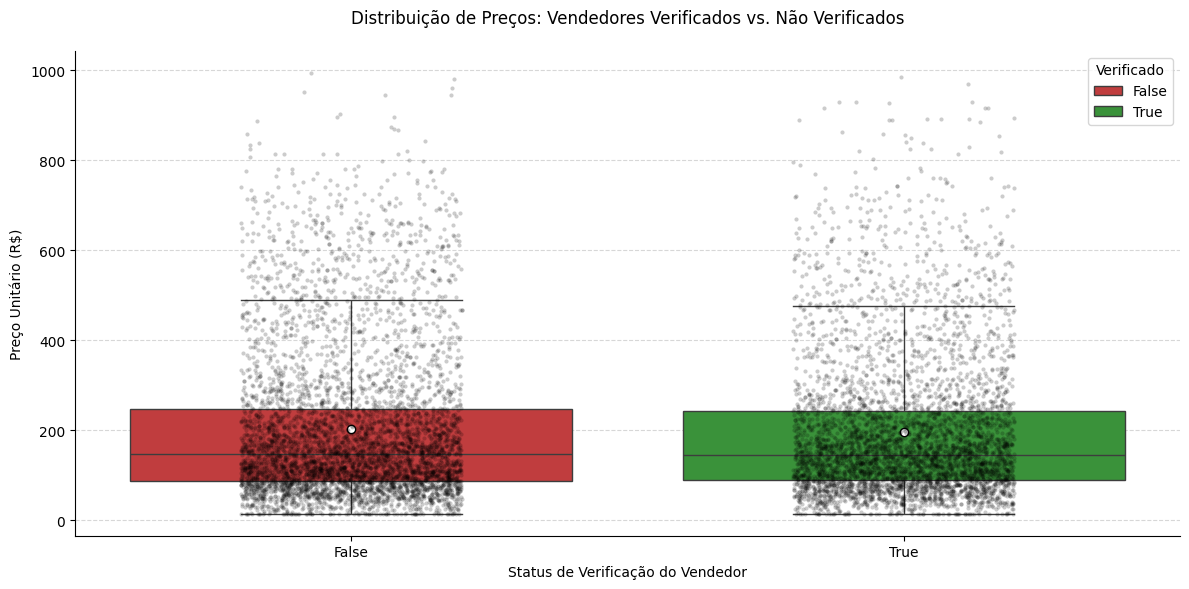

In [19]:
df_expandido = df_vendas_merged.loc[df_vendas_merged.index.repeat(df_vendas_merged['quantidade'])]

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    color='black',
    size=3,
    alpha=0.2,
    jitter=0.2
)

plt.title('Distribuição de Preços: Vendedores Verificados vs. Não Verificados', pad=20)
plt.xlabel('Status de Verificação do Vendedor')
plt.ylabel('Preço Unitário (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

In [20]:
df_expandido

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,data_pedido_dt,_hora_pedido,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,NaN,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,NaN,2023-10-21,1900-01-01 16:01:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.0,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,1337.26,39.09,SP,Em trânsito,NaN,2023-04-23,1900-01-01 10:34:00,False
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,1337.26,39.09,SP,Em trânsito,NaN,2023-04-23,1900-01-01 10:34:00,False
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,1337.26,39.09,SP,Em trânsito,NaN,2023-04-23,1900-01-01 10:34:00,False


# 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

## Quantidade de Vendedores (Verificado x Não Verificado) por Hora do Pedido

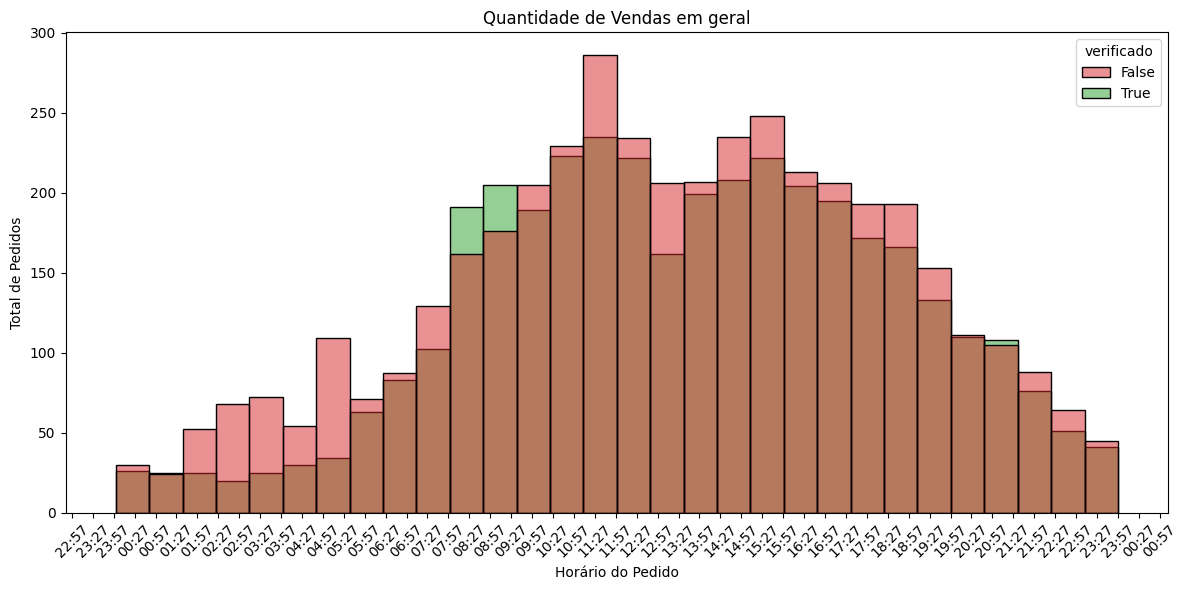

In [22]:
vendas_status_geral = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_geral,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas em geral", fontsize=12)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

In [19]:
# Vendedores com horáios atipicos (2h-5h)

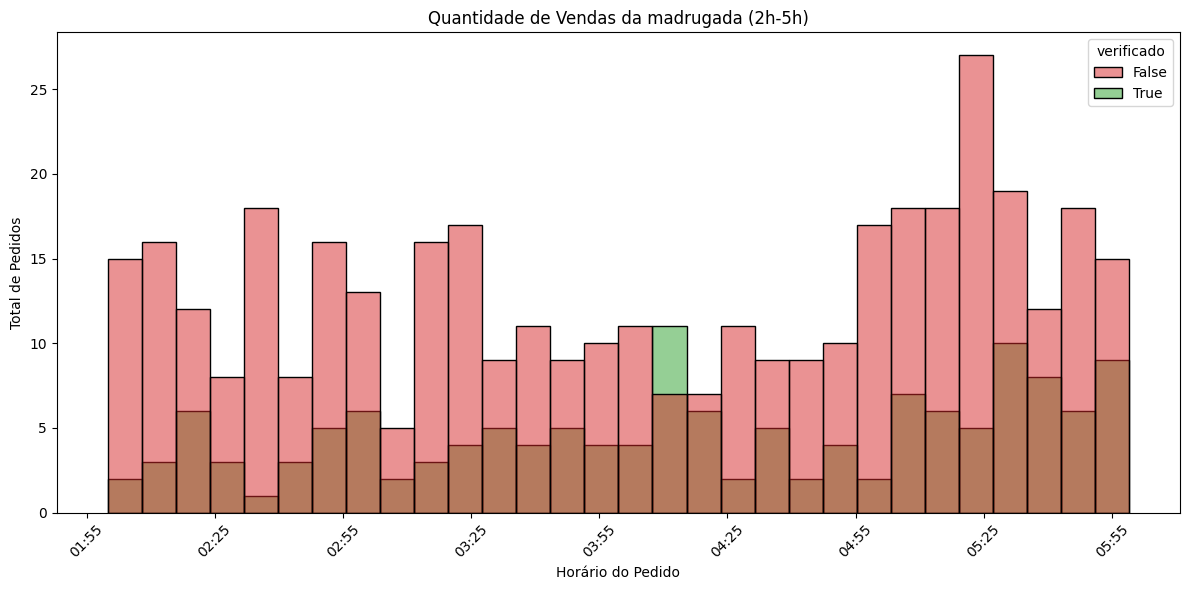

In [23]:

df_vendas_2_5 = df_vendas.query('_hora_pedido.dt.hour >= 2 and _hora_pedido.dt.hour <= 5')

vendas_status_2_5 = df_vendas_2_5.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_2_5,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas da madrugada (2h-5h)")
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Vendedor')

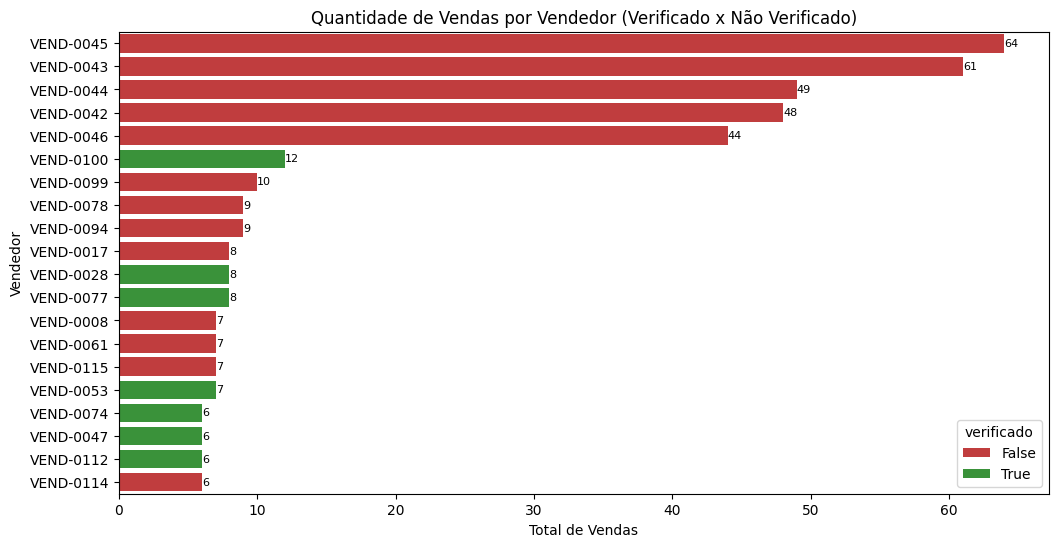

In [25]:
quantidade_vendas_por_vendedor = vendas_status_2_5.groupby(['vendedor_id', 'verificado']
                    )['quantidade'].sum().reset_index(name='total_vendas'
                    ).sort_values(by='total_vendas', ascending=False)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    quantidade_vendas_por_vendedor.head(20),
    x='total_vendas',
    y='vendedor_id',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Quantidade de Vendas por Vendedor (Verificado x Não Verificado)")
plt.xlabel("Total de Vendas")
plt.ylabel("Vendedor")

Conclusão: Aparentemente a hora de entrada não será utilziada

# 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

Tempo de Criação de Conta

In [26]:
df_avl_suspeitas_info = df_avl_suspeitas.merge(df_vendedores, 
                                               on='vendedor_id', how='left')

df_avl_suspeitas_info['tempo_criacao_conta'] = (
    df_avl_suspeitas_info['data_avaliacao_dt'] - df_avl_suspeitas['data_criacao_conta_dt']
).dt.days

df_avl_suspeitas_info

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,data_avaliacao_dt,data_criacao_conta_dt,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt,tempo_criacao_conta
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,Loja EPNPN,2022-03-05,Salvador,PE,Casa & Decoração,1575,2.9,23,True,2022-03-05,378
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,Loja TTRVV,2021-12-30,Belo Horizonte,MA,Acessórios,1107,4.3,26,True,2021-12-30,277
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,Loja VLJBA,2020-11-25,Manaus,MG,Eletrônicos,278,3.8,10,True,2020-11-25,189
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,Loja ZANLX,2020-09-10,Porto Alegre,MG,Esporte & Lazer,1765,4.3,18,False,2020-09-10,356
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,Loja AFRXX,2020-05-25,Brasília,RJ,Infantil,204,4.5,16,True,2020-05-25,412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,Sem Comentário Explícito,2023-12-26,2023-09-25,Loja ATTPS,2022-01-04,Belo Horizonte,PI,Infantil,680,4.1,18,False,2022-01-04,92
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11,1
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,Loja YZZMG,2021-05-30,Belo Horizonte,PR,Moda Masculina,793,2.7,17,False,2021-05-30,55
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,Loja EPZCI,2022-03-07,Brasília,GO,Acessórios,1156,4.4,2,True,2022-03-07,136


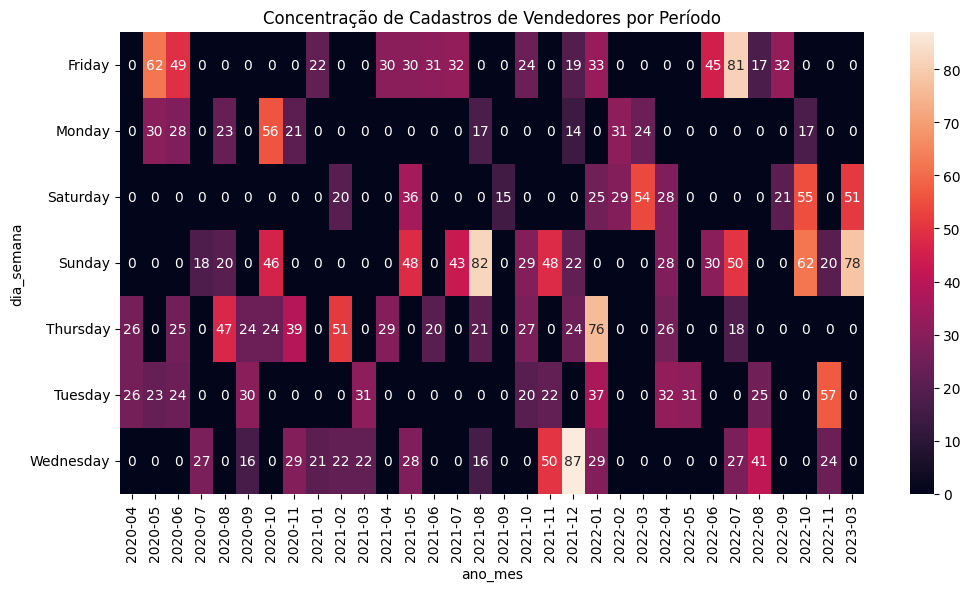

In [27]:
df_avl_suspeitas_info['ano_mes'] = df_avl_suspeitas_info['_data_cadastro_dt'].dt.to_period('M')
df_avl_suspeitas_info['dia_semana'] = df_avl_suspeitas_info['_data_cadastro_dt'].dt.day_name()

pivot_cluster = df_avl_suspeitas_info.pivot_table(
    index='dia_semana', 
    columns='ano_mes', 
    values='vendedor_id', 
    aggfunc='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_cluster, annot=True)
plt.title('Concentração de Cadastros de Vendedores por Período')
plt.show()
picos_mes = df_avl_suspeitas_info.groupby('ano_mes').size()
meses_suspeitos = picos_mes[picos_mes > 50].index

In [29]:
df_avl_suspeitas_info['is_cluster_cadastro'] = df_avl_suspeitas_info['ano_mes'].isin(meses_suspeitos)
df_avl_suspeitas_info[df_avl_suspeitas_info['is_cluster_cadastro']]

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,data_avaliacao_dt,data_criacao_conta_dt,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt,tempo_criacao_conta,ano_mes,dia_semana,is_cluster_cadastro
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,Loja EPNPN,2022-03-05,Salvador,PE,Casa & Decoração,1575,2.9,23,True,2022-03-05,378,2022-03,Saturday,True
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,Loja TTRVV,2021-12-30,Belo Horizonte,MA,Acessórios,1107,4.3,26,True,2021-12-30,277,2021-12,Thursday,True
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,Loja VLJBA,2020-11-25,Manaus,MG,Eletrônicos,278,3.8,10,True,2020-11-25,189,2020-11,Wednesday,True
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,Loja ZANLX,2020-09-10,Porto Alegre,MG,Esporte & Lazer,1765,4.3,18,False,2020-09-10,356,2020-09,Thursday,True
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,Loja AFRXX,2020-05-25,Brasília,RJ,Infantil,204,4.5,16,True,2020-05-25,412,2020-05,Monday,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,Sem Comentário Explícito,2023-12-26,2023-09-25,Loja ATTPS,2022-01-04,Belo Horizonte,PI,Infantil,680,4.1,18,False,2022-01-04,92,2022-01,Tuesday,True
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11,1,2023-03,Saturday,True
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,Loja YZZMG,2021-05-30,Belo Horizonte,PR,Moda Masculina,793,2.7,17,False,2021-05-30,55,2021-05,Sunday,True
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,Loja EPZCI,2022-03-07,Brasília,GO,Acessórios,1156,4.4,2,True,2022-03-07,136,2022-03,Monday,True


Casos Nota 5

In [31]:
df_nota5 = df_avl_suspeitas_info.query("nota == 5")
df_nota5['verificado'].value_counts()

verificado
False    635
True     555
Name: count, dtype: int64

In [32]:
df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta'].describe()

count    635.00
mean     329.24
std      229.78
min        1.00
25%      122.00
50%      317.00
75%      527.50
max      730.00
Name: tempo_criacao_conta, dtype: float64

In [33]:
df_nota5[df_nota5['verificado'] == True]['tempo_criacao_conta'].describe()

count    555.0
mean     383.2
std      201.5
min       31.0
25%      205.5
50%      375.0
75%      554.0
max      729.0
Name: tempo_criacao_conta, dtype: float64

Distribuição do Tempo de Criação da Conta

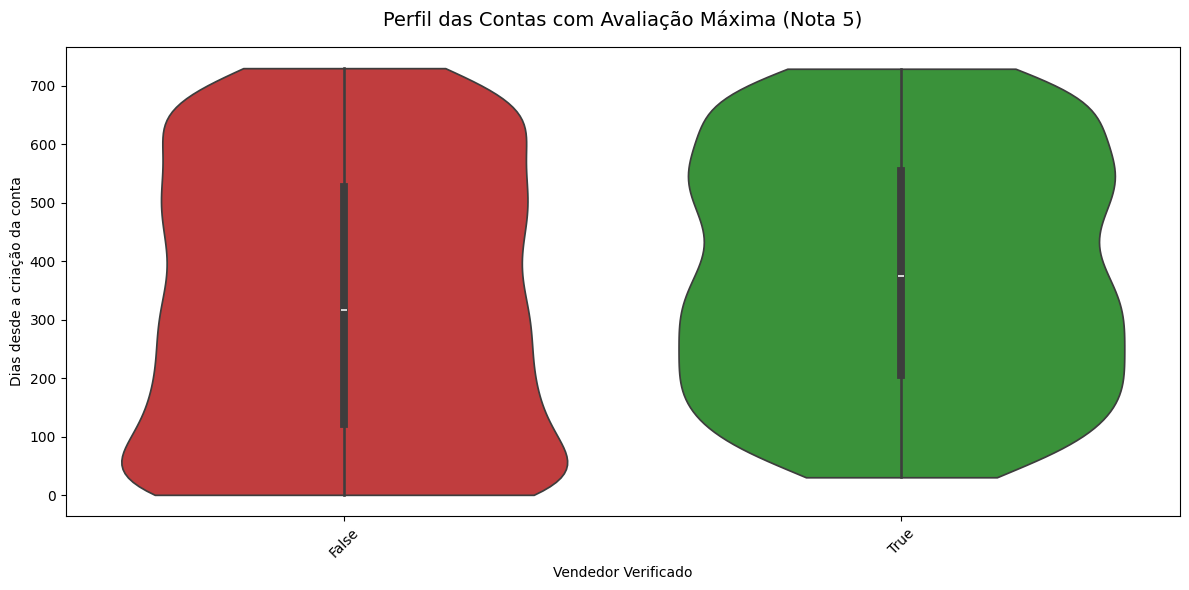

In [34]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='tempo_criacao_conta', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.xticks(rotation=45)
plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

<Axes: xlabel='verificado', ylabel='tempo_criacao_conta'>

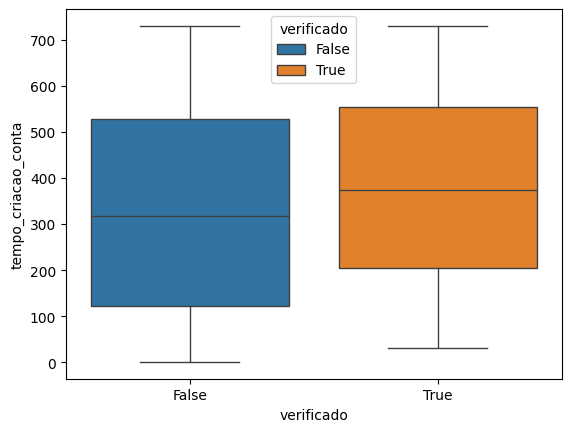

In [35]:
sns.boxplot(data=df_nota5, 
            y='tempo_criacao_conta', 
            x='verificado',
            hue='verificado')

Definição do Limite de Criação da Conta

In [36]:
df_nota5['tempo_criacao_conta'].value_counts().reset_index(name='count').sort_values(by='count', ascending=False).head(15)

,tempo_criacao_conta,count
0,1,18
1,6,17
2,4,13
3,2,12
4,5,11
5,3,9
6,548,6
7,195,6
8,475,5
9,258,5


In [37]:
df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta'].quantile([0.25, 0.5, 0.75])

0.25    122.0
0.50    317.0
0.75    527.5
Name: tempo_criacao_conta, dtype: float64

In [38]:
df_nota5[df_nota5['verificado'] == True]['tempo_criacao_conta'].quantile([0.25, 0.5, 0.75])

0.25    205.5
0.50    375.0
0.75    554.0
Name: tempo_criacao_conta, dtype: float64

In [39]:
limite_principal = df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta'].quantile(0.25)

# Análise de Reclamações

<Axes: xlabel='verificado', ylabel='reclamacoes'>

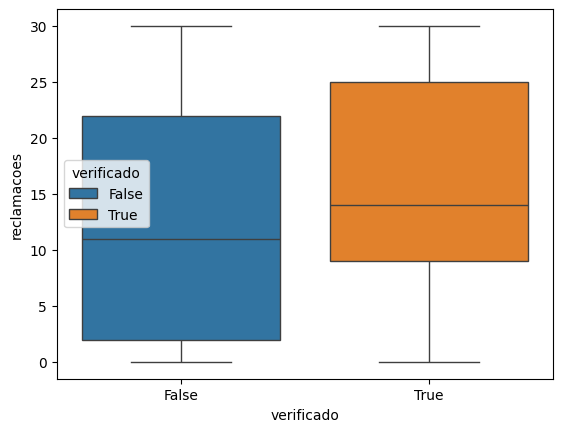

In [51]:
sns.boxplot(data=df_avl_suspeitas_info.query("nota == 5"), 
            y='reclamacoes', 
            x='verificado',
            hue='verificado')

In [52]:
df_nota5['reclamacoes'].value_counts().reset_index(name='quantidade').sort_values(by='quantidade',ascending=False)

,reclamacoes,quantidade
0,0,114
1,23,85
2,2,62
3,25,59
4,13,59
5,5,55
6,4,54
7,10,51
8,27,50
9,26,48


Análise de IP

In [107]:
df_ip_origem = df_nota5.groupby(
    ['ip_origem','vendedor_id', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_ip').sort_values(by='contagem_por_ip', ascending=False)

df_ip_origem.head(40)

,ip_origem,vendedor_id,verificado,contagem_por_ip
441,192.168.1.100,VEND-0043,False,9
443,192.168.1.100,VEND-0045,False,8
453,192.168.1.105,VEND-0045,False,7
454,192.168.1.105,VEND-0046,False,7
444,192.168.1.100,VEND-0046,False,7
442,192.168.1.100,VEND-0044,False,6
450,192.168.1.105,VEND-0042,False,5
451,192.168.1.105,VEND-0043,False,5
446,192.168.1.102,VEND-0043,False,5
447,192.168.1.102,VEND-0044,False,5


Top IPS

Text(0, 0.5, 'IP de origem')

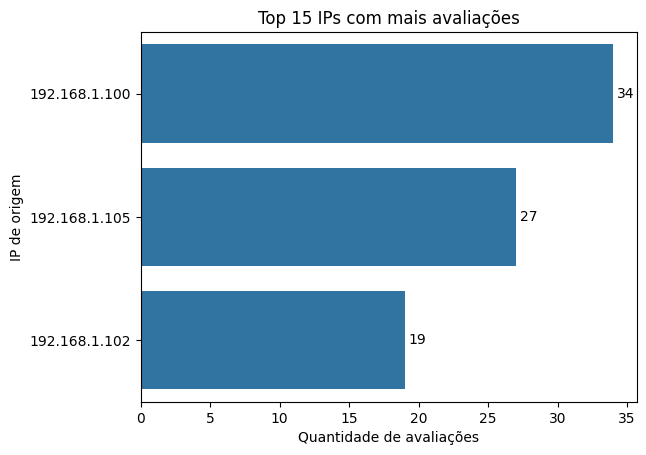

In [58]:
top_ips = df_ip_origem.groupby("ip_origem")['contagem_por_ip'].sum().sort_values(ascending=False).reset_index()

ax = sns.barplot(
    data=top_ips.query('contagem_por_ip > 1').head(15),
    x='contagem_por_ip',
    y='ip_origem',
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Top 15 IPs com mais avaliações')
plt.xlabel('Quantidade de avaliações')
plt.ylabel('IP de origem')

Análise de Rede/Subrede

In [59]:
df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
df_nota5['subrede_local'] = df_nota5['ip_origem'].str.split(".").str[0:3].str.join(".")


C:\Users\rpf97\AppData\Local\Temp\ipykernel_12128\1169564160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_12128\1169564160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_12128\1169564160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a 

In [60]:
df_nota5.groupby(
    ['rede','vendedor_id', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_ip').sort_values(by='contagem_por_ip', ascending=False)


,rede,vendedor_id,verificado,contagem_por_ip
435,192,VEND-0043,False,19
437,192,VEND-0045,False,19
438,192,VEND-0046,False,17
436,192,VEND-0044,False,14
434,192,VEND-0042,False,11
...,...,...,...,...
1077,95,VEND-0049,True,1
1078,95,VEND-0062,True,1
1079,96,VEND-0003,True,1
1080,96,VEND-0005,False,1


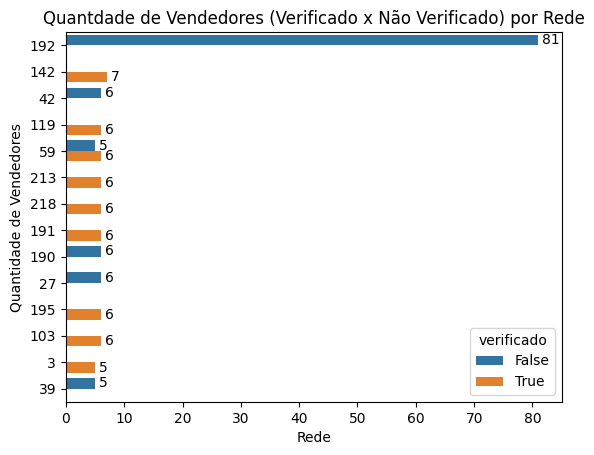

In [61]:
df_ip_rede = df_nota5.groupby(
    ['rede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_ip_rede').sort_values(by='contagem_ip_rede', ascending=False)

ax = sns.barplot(
    data=df_ip_rede.head(15),
    y='rede',
    x='contagem_ip_rede', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por Rede")
plt.xlabel("Rede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

Ponto de Atenção: Simplificar o IP como rede não funcionaria pois apresenta um conjunto mais amplo

In [62]:
df_nota5.groupby(
    ['subrede','vendedor_id', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_ip_subrede').sort_values(by='contagem_por_ip_subrede', ascending=False).head(15)


,subrede,vendedor_id,verificado,contagem_por_ip_subrede
441,192.168,VEND-0043,False,19
443,192.168,VEND-0045,False,19
444,192.168,VEND-0046,False,17
442,192.168,VEND-0044,False,14
440,192.168,VEND-0042,False,11
1098,96.141,VEND-0073,True,1
11,10.34,VEND-0112,True,1
1114,99.52,VEND-0054,True,1
0,1.11,VEND-0115,False,1
1,1.133,VEND-0010,True,1


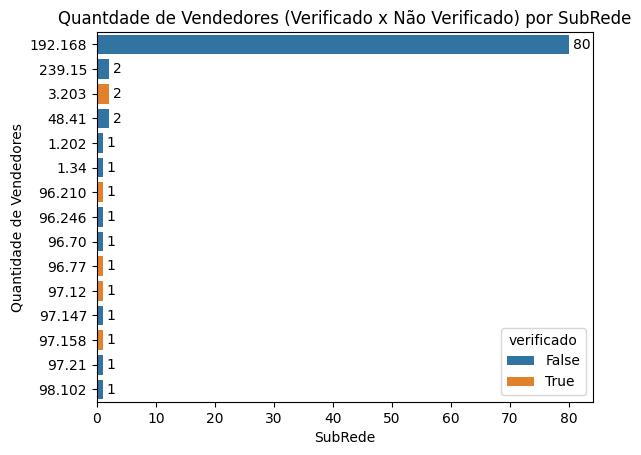

In [63]:
df_ip_subrede = df_nota5.groupby(
    ['subrede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_subrede').sort_values(by='contagem_por_subrede', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede.head(15),
    y='subrede',
    x='contagem_por_subrede', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede")
plt.xlabel("SubRede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

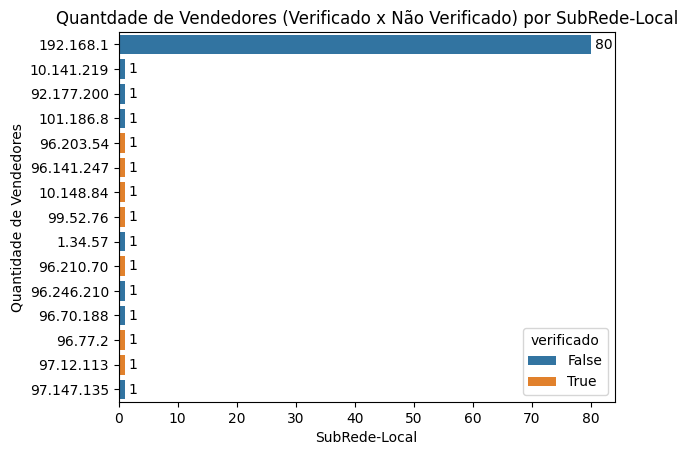

In [64]:
df_ip_subrede_local = df_nota5.groupby(
    ['subrede_local', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_subrede_local').sort_values(by='contagem_por_subrede_local', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede_local.head(15),
    y='subrede_local',
    x='contagem_por_subrede_local', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede-Local")
plt.xlabel("SubRede-Local")
plt.ylabel("Quantidade de Vendedores")
plt.show()

Quantidade de textos mais comuns por vendedor

In [65]:
df_textos = df_nota5.groupby(
    ['texto_avaliacao', 'verificado'], dropna=False
).size().reset_index(name='contagem')

top_textos = df_textos.sort_values('contagem', ascending=False).head(15)
top_textos

,texto_avaliacao,verificado,contagem
5,Excelente custo-benefício.,False,78
17,"Recomendo, boa experiência.",True,75
10,Não gostei da qualidade.,True,74
21,"Veio com defeito, pedi troca.",False,65
14,"Produto ok, dentro do esperado.",False,63
1,Bom produto pelo preço.,True,61
12,Produto diferente da foto.,True,61
9,Não gostei da qualidade.,False,61
15,"Produto ok, dentro do esperado.",True,61
16,"Recomendo, boa experiência.",False,60


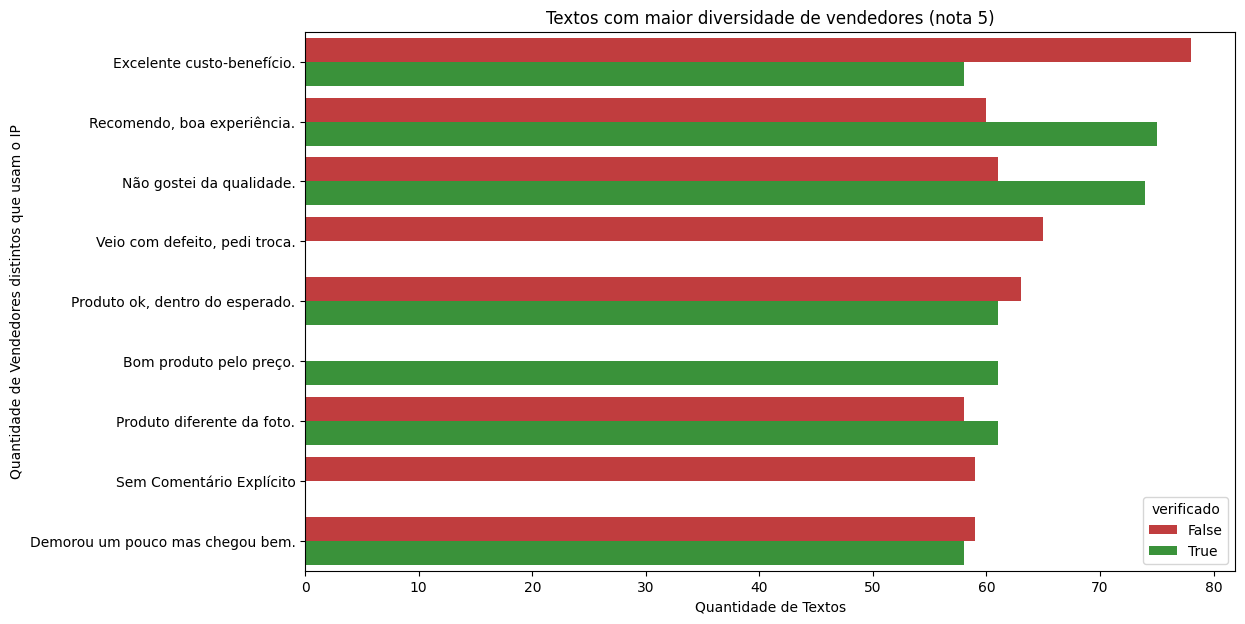

In [66]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_textos,
    x='contagem',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

plt.title('Textos com maior diversidade de vendedores (nota 5)')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Quantidade de Vendedores distintos que usam o IP')
plt.show()

Quantidade de Categorias por Vendedor (Verificado x Não Verificado)

In [67]:
def_quant_categorias = df_nota5.groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem_categorial_principal').sort_values(by='contagem_categorial_principal', ascending=False)

def_quant_categorias

,categoria_principal,verificado,contagem_categorial_principal
5,Casa & Decoração,True,128
8,Esporte & Lazer,False,119
4,Casa & Decoração,False,92
15,Moda Masculina,True,91
12,Moda Feminina,False,90
6,Eletrônicos,False,84
9,Esporte & Lazer,True,80
14,Moda Masculina,False,73
11,Infantil,True,66
10,Infantil,False,65


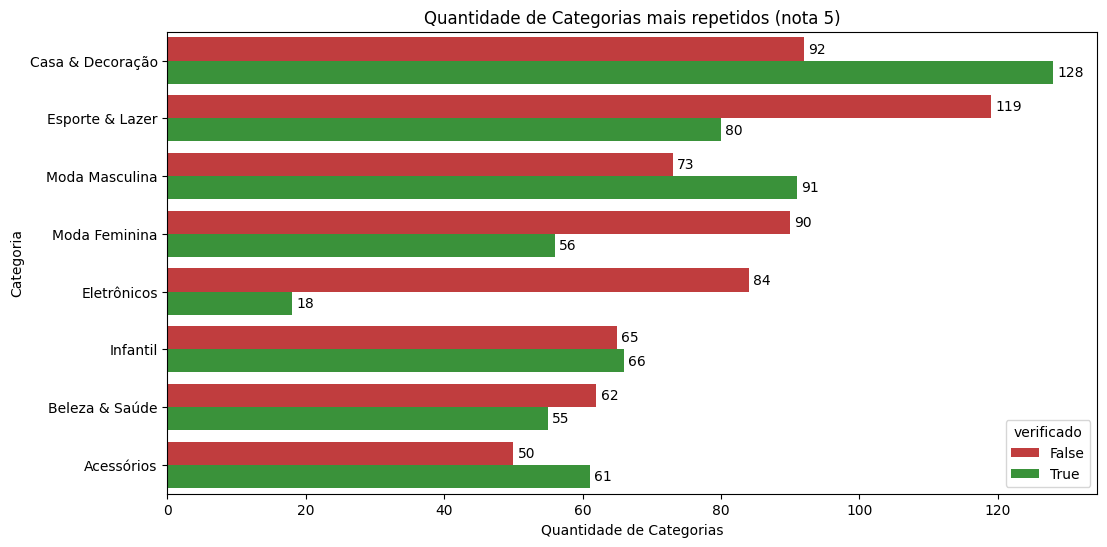

In [68]:
plt.figure(figsize=(12,6))
ax = sns.barplot(
    def_quant_categorias,
    x='contagem_categorial_principal',
    y='categoria_principal',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'} 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Quantidade de Categorias mais repetidos (nota 5)')
plt.xlabel("Quantidade de Categorias")
plt.ylabel("Categoria")
plt.show()

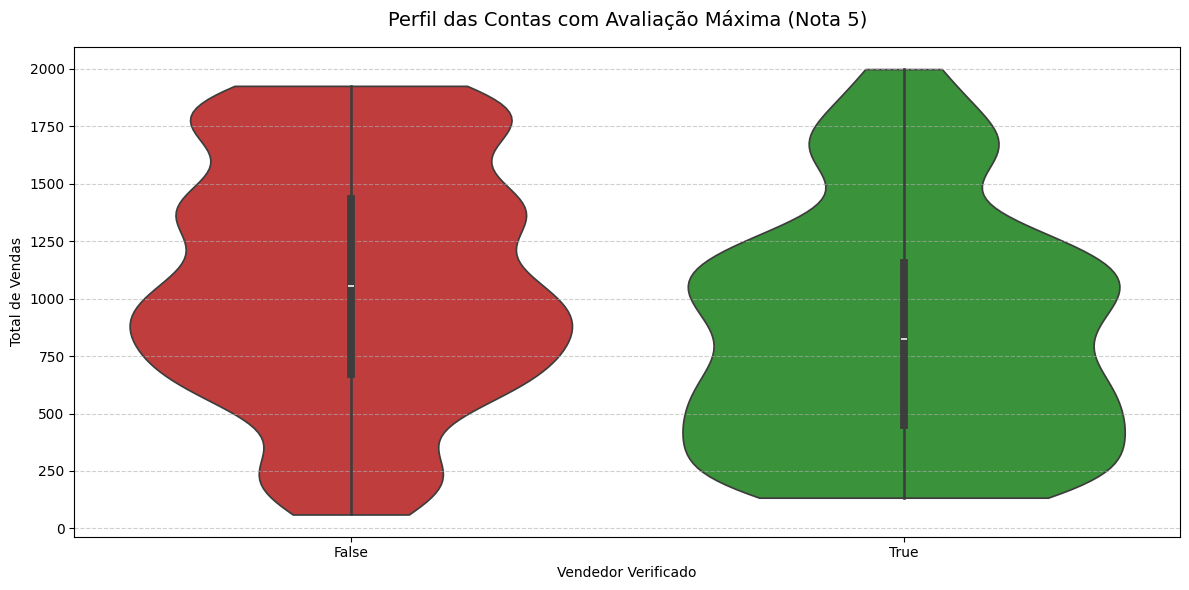

In [69]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='total_vendas', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

# Estilização extra
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos
plt.ylabel('Total de Vendas')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

Vendedores Suspeitos

In [ ]:
df_avl_suspeitas_info['subrede'] = df_avl_suspeitas_info['ip_origem'].str.split(".").str[0:2].str.join(".")

df_avl_suspeitas_info['possui_ips_repetidos'] = (
    df_avl_suspeitas_info.groupby(['subrede', 'verificado'])['vendedor_id'].transform("size") > 1
)

df_avl_suspeitas_info['possui_textos_repetidos'] = (
    df_avl_suspeitas_info.groupby(['texto_avaliacao', 'verificado'])['vendedor_id'].transform("size") > 1
)

df_avl_suspeitas_info['possui_reclamacoes'] = (df_avl_suspeitas_info['reclamacoes'] > 0)

In [133]:
df_avl_suspeitas_info[df_avl_suspeitas_info['possui_ips_repetidos']]['nota']

7       4
14      4
35      5
45      5
53      5
       ..
2928    4
2938    5
2988    5
2991    5
2996    5
Name: nota, Length: 152, dtype: int64

In [146]:

df_avl_suspeitas_info['score'] = (
    ((df_avl_suspeitas_info['possui_ips_repetidos'] & (df_avl_suspeitas_info['nota'] == 5)).astype("int") * 5)
    
    + (df_avl_suspeitas_info['possui_textos_repetidos'] & (df_avl_suspeitas_info['nota'] == 5)).astype("int")
    
    + ((df_avl_suspeitas_info['possui_reclamacoes']) & (df_avl_suspeitas_info['nota'] == 5)).astype("int")
    
    + (((df_avl_suspeitas_info['tempo_criacao_conta'] < limite_principal) 
       & (df_avl_suspeitas_info['nota'] == 5)).astype("int") * 5)
).astype("int")

In [147]:
df_casos_suspeitos = df_avl_suspeitas_info[df_avl_suspeitas_info['score'] >= 10]

df_casos_suspeitos[
    ['vendedor_id', 'avaliacao_id', 'ip_origem', 'nota', 'subrede', 
     'data_criacao_conta_dt', 'data_avaliacao_dt', 'tempo_criacao_conta', 'reclamacoes',
     'texto_avaliacao', 'possui_ips_repetidos', 'possui_textos_repetidos']
].sort_values(by='avaliacao_id')

,vendedor_id,avaliacao_id,ip_origem,nota,subrede,data_criacao_conta_dt,data_avaliacao_dt,tempo_criacao_conta,reclamacoes,texto_avaliacao,possui_ips_repetidos,possui_textos_repetidos
35,VEND-0002,AVAL-00036,48.41.128.155,5,48.41,2024-02-04,2024-04-27,83,16,"Recomendo, boa experiência.",True,True
45,VEND-0042,AVAL-00046,192.168.1.100,5,192.168,2024-01-11,2024-01-13,2,2,Entrega rápida e produto de qualidade!,True,True
53,VEND-0042,AVAL-00054,192.168.1.102,5,192.168,2024-04-01,2024-04-03,2,2,Entrega rápida e produto de qualidade!,True,True
99,VEND-0042,AVAL-00100,192.168.1.102,5,192.168,2023-12-26,2024-01-01,6,2,Superou minhas expectativas! 10/10,True,True
124,VEND-0043,AVAL-00125,192.168.1.105,5,192.168,2024-06-20,2024-06-26,6,2,Excelente produto! Recomendo muito!,True,True
143,VEND-0044,AVAL-00144,192.168.1.100,5,192.168,2023-11-22,2023-11-23,1,0,Melhor compra que já fiz! Recomendo!,True,True
202,VEND-0046,AVAL-00203,192.168.1.102,5,192.168,2023-12-03,2023-12-05,2,0,Melhor compra que já fiz! Recomendo!,True,True
297,VEND-0045,AVAL-00298,192.168.1.100,5,192.168,2024-11-25,2024-12-01,6,0,"Produto incrível, vendedor nota 10!",True,True
480,VEND-0043,AVAL-00481,192.168.1.100,5,192.168,2023-05-06,2023-05-11,5,2,Entrega rápida e produto de qualidade!,True,True
527,VEND-0044,AVAL-00528,192.168.1.102,5,192.168,2023-05-03,2023-05-06,3,0,Excelente produto! Recomendo muito!,True,True


## 3. **Os vendedores suspeitos compartilham características em comum?** Cruze com o cadastro: data de cadastro próxima, mesma cidade, nomes similares, não verificados.

Filtro dos Vendedores Suspeitos

In [104]:
df_casos_suspeitos['vendedor_id'].tolist()

['VEND-0002',
 'VEND-0042',
 'VEND-0042',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0042',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043',
 'VEND-0042',
 'VEND-0043',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0043',
 'VEND-0042',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043',
 'VEND-0042',
 'VEND-0043',
 'VEND-0043']

In [105]:
lista_ids_suspeitos = df_casos_suspeitos['vendedor_id'].tolist()

df_vendedores['is_suspect'] = df_vendedores['vendedor_id'].isin(lista_ids_suspeitos)

In [106]:
df_vendedores[df_vendedores['is_suspect']]

,vendedor_id,nome_loja,data_cadastro,cidade,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt,is_suspect,semana
1,VEND-0002,Loja UJZHR,2022-11-29,Belo Horizonte,PA,Beleza & Saúde,192,4.4,16,False,2022-11-29,True,48
41,VEND-0042,Loja XYZ03,2023-03-12,Fortaleza,CE,Infantil,980,4.9,2,False,2023-03-12,True,10
42,VEND-0043,Loja XYZ04,2023-03-11,Fortaleza,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11,True,10


Vendedores com a mesma cidade

In [102]:
df_vendedores[df_vendedores['is_suspect']].groupby(['cidade', 'verificado'])['vendedor_id'].size()

cidade          verificado
Belo Horizonte  False         1
Fortaleza       False         2
Name: vendedor_id, dtype: int64

Quantidade de Lojas com o mesmo nome

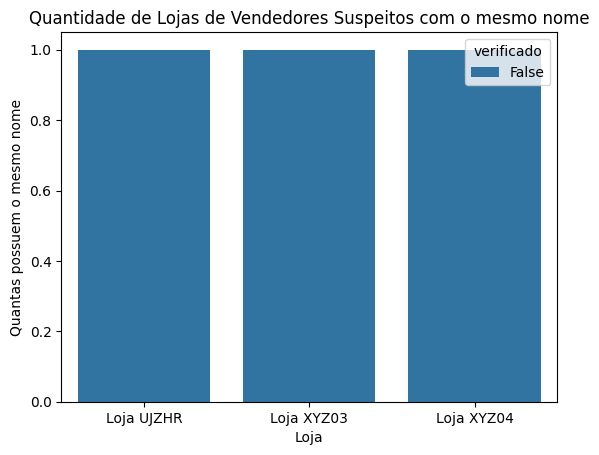

In [99]:
df_nome_lojas = df_vendedores[df_vendedores['is_suspect']].groupby(['nome_loja', 'verificado'])\
                            .size().reset_index(name='quant_lojas').sort_values(by='quant_lojas')

sns.barplot(
    data=df_nome_lojas,
    x='nome_loja',
    y='quant_lojas',
    hue='verificado'
)

plt.title("Quantidade de Lojas de Vendedores Suspeitos com o mesmo nome")
plt.xlabel("Loja")
plt.ylabel("Quantas possuem o mesmo nome")
plt.show()

Análise da Semana_Cadastro de Cadastro

In [100]:
df_vendedores['semana'] = df_vendedores['_data_cadastro_dt'].dt.isocalendar().week

In [101]:
df_vendedores[df_vendedores['is_suspect']]\
            .groupby(['_data_cadastro_dt', 'semana'])['nome_loja']\
            .value_counts().reset_index(name='quantidade_lojas')

,_data_cadastro_dt,semana,nome_loja,quantidade_lojas
0,2022-11-29,48,Loja UJZHR,1
1,2023-03-11,10,Loja XYZ04,1
2,2023-03-12,10,Loja XYZ03,1


## 4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

In [149]:
vendas_suspeitas = df_vendedores[df_vendedores['is_suspect']].merge(df_vendas, 
                               left_on=['vendedor_id','categoria_principal'],
                               right_on=['vendedor_id', 'categoria']
                               , how='left')

faturamento_suspeito = vendas_suspeitas['valor_total'].sum()

print(f"O impacto financeiro total dos vendedores suspeitos é: R$ {faturamento_suspeito:,.2f}")

O impacto financeiro total dos vendedores suspeitos é: R$ 15,225.61


Percentual do Total Geral

In [123]:
faturamento_total = df_vendas['valor_total'].sum()

percentual_impactado = faturamento_suspeito/faturamento_total * 100

print(f"O Custo dos valores suspeitos representa {percentual_impactado:.2f}% do faturamento total da plataforma.")

O Custo dos valores suspeitos representa 0.77% do faturamento total da plataforma.


## 5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

In [ ]:
# Calculo Percentual dos produtos Devolvidos ou cancelados

In [ ]:
df_vendas['foi_cancelado_devolvido'] = df_vendas['status_pedido'].isin(['Devolvido', 'Cancelado']).astype("int")

taxa_geral = df_vendas['foi_cancelado_devolvido'].mean() * 100
taxa_suspeitos = df_vendas[df_vendas['vendedor_id'].isin(lista_ids_suspeitos)]['foi_cancelado_devolvido'].mean() * 100
taxas_normais = df_vendas[~df_vendas['vendedor_id'].isin(lista_ids_suspeitos)]['foi_cancelado_devolvido'].mean() * 100

print(f"Taxa Geral: {taxa_geral:.2f} %")
print(f"Taxa dos Vendedores Suspeitos: {taxa_suspeitos:.2f} %")
print(f"Taxa dos Outros Vendedores: {taxas_normais:.2f} %")


Taxa Geral: 24.52%
Taxa dos Vendedores Suspeitos: 22.16%
Taxa dos Outros Vendedores: 24.65%


Conclusão: a taxa de cancelamento/devolução dos vendedores suspeitos é abaixo da taxa geral

## 6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?


## 7. **Proponha regras automáticas** para detectar fraudes futuras baseadas nos padrões descobertos.


Regras

1 O Horário é Irrelevante até o Momento